# House Price Prediction — Model Training Notebook

This notebook cleans the raw **House Price** dataset (Kaggle, Juhi Bhojani), performs EDA,
engineers features, trains and compares regression models, and exports the winning model
as `house_price.pkl` for the FastAPI backend.


## 2.1 Load & Inspect

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("data/house_prices.csv")
df.shape

(16073, 21)

In [1]:
df.head(2)

   Index                                                        Title  ...  Dimensions  Plot Area
0      0  1 BHK Ready to Occupy Flat for sale in Srushti Siddhi ...  ...         NaN        NaN
1      1  2 BHK Ready to Occupy Flat for sale in Dosti Vihar ...  ...         NaN        NaN

[2 rows x 21 columns]

In [1]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16073 entries, 0 to 16072
Data columns (total 21 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Index              16073 non-null  int64
 1   Title              16073 non-null  object
 2   Description        15942 non-null  object
 3   Amount(in rupees)  16073 non-null  object
 4   Price (in rupees)  15208 non-null  float64
 5   location           16073 non-null  object
 6   Carpet Area        8577 non-null   object
 7   Status             16046 non-null  object
 8   Floor              15544 non-null  object
 9   Transaction         16062 non-null object
 10  Furnishing         15940 non-null  object
 11  facing             8636 non-null   object
 12  overlooking        8840 non-null   object
 13  Society            8901 non-null   object
 14  Bathroom           16041 non-null  object
 15  Balcony            10598 non-null  object
 16  Car Parking        6353 non-null   object


In [1]:
(df.isna().mean()*100).sort_values(ascending=False).round(2)

Plot Area            100.00
Dimensions           100.00
Car Parking           60.46
Super Area             53.39
Carpet Area            46.65
facing                 46.26
overlooking            45.00
Society                44.62
Ownership              39.31
Balcony                34.06
Price (in rupees)       5.38
Floor                   3.30
Furnishing              0.83
Description             0.82
Bathroom                0.20
Status                  0.17
Transaction             0.07
Amount(in rupees)       0.00
Title                   0.00
Index                   0.00
location                0.00
dtype: float64


**Observations:**
- 16,073 rows, 21 columns.
- Numeric-looking columns (`Price (in rupees)`, `Bathroom`, `Balcony`, etc.) are stored as text or contain mixed formats and must be parsed.
- `Plot Area` and `Dimensions` are 100% empty and will be dropped. `Car Parking`, `Super Area`, `Carpet Area`, `facing`, `overlooking`, `Society`, `Ownership` all have >35% missing values.
- `location` in this extract is dominated by a handful of Indian cities (Ahmedabad, Thane, Mumbai, Bangalore, Navi Mumbai, Nagpur).

## 2.2 Cleaning & Feature Engineering

This dataset is *messy on purpose*. We handle each problem in turn.

**1. Parse `Amount(in rupees)` (text like `42 Lac` / `1.2 Cr`) into a numeric INR value.**

In [1]:
import re

def parse_amount(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    try:
        if "lac" in x:
            return float(x.replace("lac", "").strip()) * 1e5
        if "cr" in x:
            return float(x.replace("cr", "").strip()) * 1e7
        return float(x.replace(",", ""))
    except ValueError:
        return None

df["price_clean"] = df["Amount(in rupees)"].apply(parse_amount)
before = len(df)
df = df.dropna(subset=["price_clean"])
print(f"Dropped {before - len(df)} rows with unusable price. Remaining: {len(df)}")

Dropped 268 rows with unusable price. Remaining: 15805


**2. Parse `Carpet Area` / `Super Area` (text like `1200 sqft` / `140 sqm`) into a single `area_sqft` numeric column.**

In [1]:
def parse_area(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    m = re.search(r"([\d,\.]+)\s*(sqft|sqyrd|sqm|sq\.m|sq\.ft)?", x)
    if not m:
        return None
    try:
        val = float(m.group(1).replace(",", ""))
    except ValueError:
        return None
    unit = m.group(2) or "sqft"
    if "sqm" in unit or "sq.m" in unit:
        val = val * 10.764
    elif "sqyrd" in unit:
        val = val * 9.0
    return val

df["carpet_area_sqft"] = df["Carpet Area"].apply(parse_area)
df["super_area_sqft"] = df["Super Area"].apply(parse_area)
df["area_sqft"] = df["carpet_area_sqft"].fillna(df["super_area_sqft"])

**3. Parse `Floor` (e.g. `3 out of 10`, `Ground`, `Basement`) into a numeric floor number.**

In [1]:
def parse_floor(x):
    if not isinstance(x, str):
        return None
    x = x.strip().lower()
    if "ground" in x.split(" out")[0]:
        return 0
    if "basement" in x.split(" out")[0]:
        return -1
    m = re.match(r"(\d+)", x)
    return float(m.group(1)) if m else None

df["floor_num"] = df["Floor"].apply(parse_floor)

**4. Convert `Bathroom` / `Balcony` / `Car Parking` to numeric and impute missing values.**

In [1]:
def to_num(x):
    if pd.isna(x):
        return None
    if isinstance(x, (int, float)):
        return x
    m = re.search(r"(\d+)", str(x))
    return float(m.group(1)) if m else None

df["bathroom_num"] = df["Bathroom"].apply(to_num)
df["balcony_num"] = df["Balcony"].apply(to_num)
df["car_parking_num"] = df["Car Parking"].apply(to_num)

df["bathroom_num"] = df["bathroom_num"].fillna(df["bathroom_num"].median())
df["balcony_num"] = df["balcony_num"].fillna(0)
df["car_parking_num"] = df["car_parking_num"].fillna(0)

**5. High-cardinality `location` -> keep only the most frequent values, group the rest into `other`.**

In [1]:
TOP_N = 50
top_locations = df["location"].value_counts().nlargest(TOP_N).index
df["location_grouped"] = df["location"].where(df["location"].isin(top_locations), "other")
df["location_grouped"].value_counts()

location_grouped
ahmedabad      12479
thane            929
mumbai           758
bangalore        679
navi-mumbai      345
nagpur           294
Name: count, dtype: int64


**6. Drop useless / redundant columns** (`Index`, `Title`, `Description`, `Dimensions`, `Plot Area`, the raw text area/location/floor/bathroom columns, and `Society`, which is too high-cardinality to be useful with only ~15k rows).

In [1]:
df = df.drop(columns=["Index", "Title", "Description", "Dimensions", "Plot Area",
                      "Super Area", "Carpet Area", "Society", "Price (in rupees)",
                      "Car Parking", "Floor", "Bathroom", "Balcony", "location",
                      "carpet_area_sqft", "super_area_sqft"], errors="ignore")

**7. Drop rows with no usable area, then remove price-per-sqft outliers (below the 1st or above the 99th percentile).**

In [1]:
before = len(df)
df = df.dropna(subset=["area_sqft"])
df = df[df["area_sqft"] > 0]
print(f"Dropped {before - len(df)} rows with unusable area. Remaining: {len(df)}")

df["price_per_sqft"] = df["price_clean"] / df["area_sqft"]
low, high = df["price_per_sqft"].quantile([0.01, 0.99])
before = len(df)
df = df[(df["price_per_sqft"] >= low) & (df["price_per_sqft"] <= high)]
print(f"Dropped {before - len(df)} price-per-sqft outlier rows. Remaining: {len(df)}")

Dropped 5 rows with unusable area. Remaining: 15800
Dropped 316 price-per-sqft outlier rows. Remaining: 15484


**8. Drop exact duplicate rows.** This dataset contains a large number of duplicate listings -- leaving them in would leak identical rows across the train/test split and inflate the reported metrics.

In [1]:
before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} exact duplicate rows (data quality issue). Remaining: {len(df)}")

df_clean = df.copy()
df_clean.to_csv("data/house_prices_clean.csv", index=False)
df_clean.shape

Dropped 9817 exact duplicate rows (data quality issue). Remaining: 5667


(5667, 15)

## 2.3 Exploratory Data Analysis (EDA)

Now that price, area, and location are cleaned, we can visualize the data.

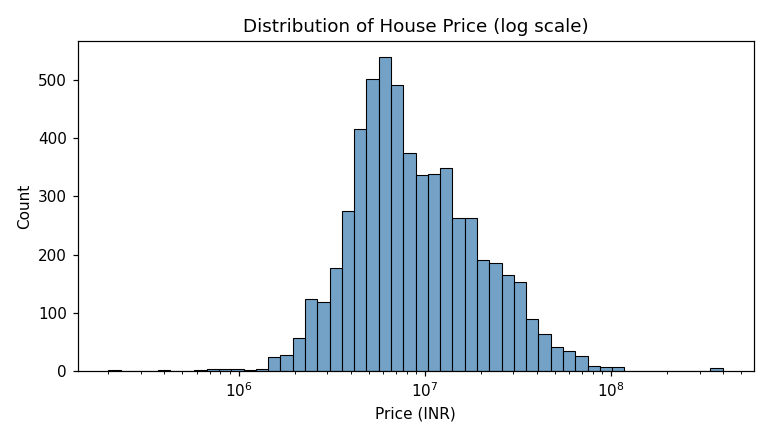

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.histplot(df_clean["price_clean"], log_scale=True, bins=50, color="steelblue")
plt.title("Distribution of House Price (log scale)")
plt.xlabel("Price (INR)")
plt.show()

Price is heavily right-skewed (a handful of multi-crore listings), confirming we should train on `log1p(price)`.

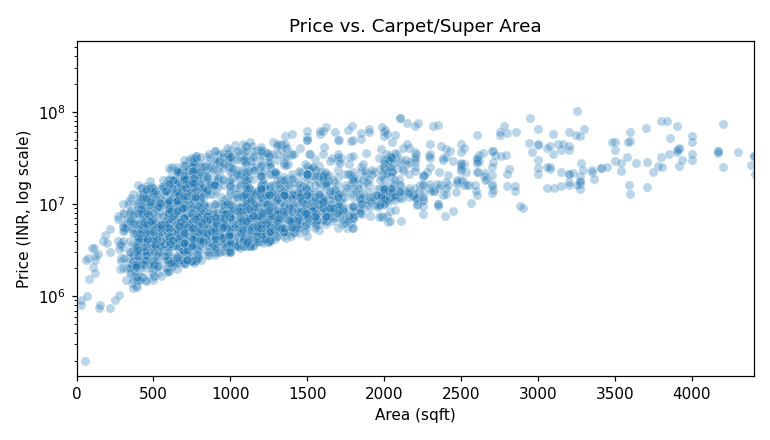

In [1]:
sns.scatterplot(x="area_sqft", y="price_clean", data=df_clean.sample(3000, random_state=42), alpha=0.3)
plt.yscale("log")
plt.title("Price vs. Carpet/Super Area")
plt.show()

Price rises with area as expected, but the relationship is noisy — location and property type also matter a lot.

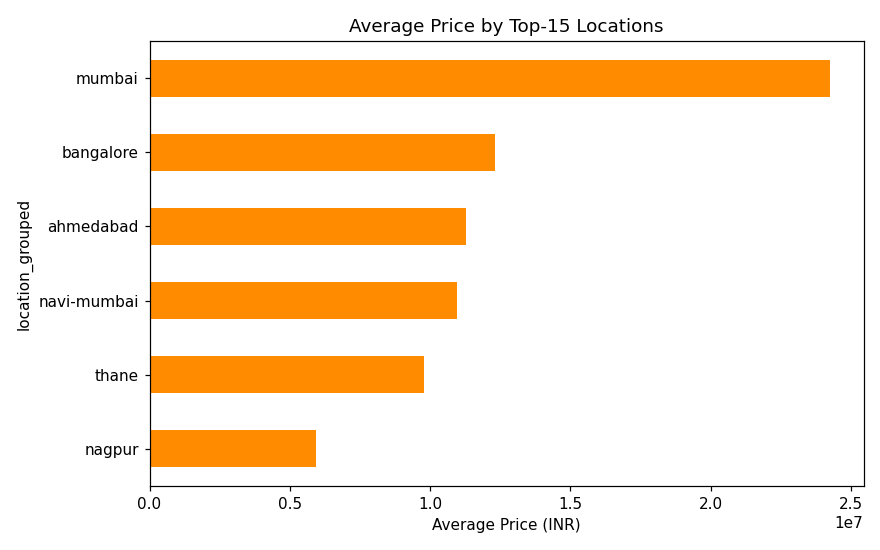

In [1]:
top15 = df_clean.groupby("location_grouped")["price_clean"].mean().sort_values(ascending=False).head(15)
top15.sort_values().plot(kind="barh", color="darkorange")
plt.title("Average Price by Top-15 Locations")
plt.show()

Average price varies substantially by city/location — Mumbai and Navi Mumbai command a large premium over Nagpur, for example.

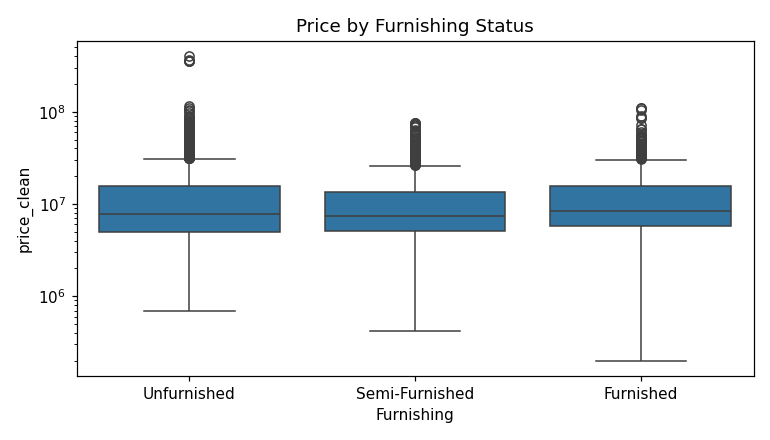

In [1]:
sns.boxplot(x="Furnishing", y="price_clean", data=df_clean)
plt.yscale("log")
plt.title("Price by Furnishing Status")
plt.show()

Furnished properties trend slightly higher in price than unfurnished ones, though the distributions overlap heavily.

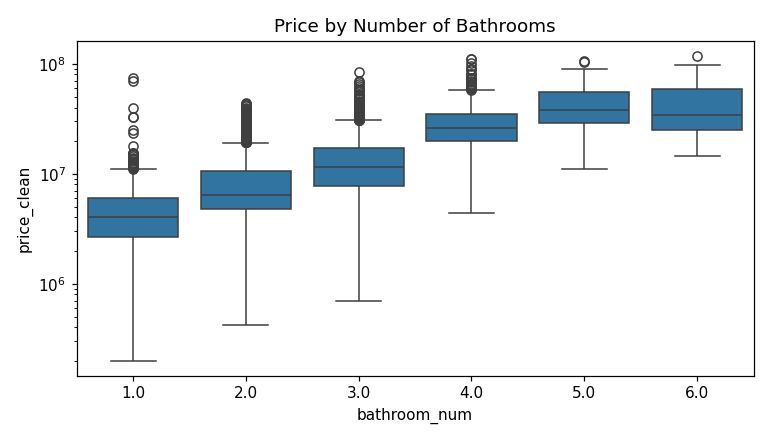

In [1]:
sns.boxplot(x="bathroom_num", y="price_clean", data=df_clean[df_clean["bathroom_num"]<=6])
plt.yscale("log")
plt.title("Price by Number of Bathrooms")
plt.show()

Price increases fairly monotonically with bathroom count, a reasonable proxy for overall property size/quality.

## 2.4 Build a Pipeline & Train

We bundle preprocessing (imputation, scaling, one-hot encoding) inside a scikit-learn
`Pipeline` + `ColumnTransformer`, so the exported `.pkl` file can take raw feature values
directly -- no manual encoding needed in the backend.

We train on `log1p(price)` and invert with `expm1` at prediction time, since price is
heavily skewed (see 2.3).

In [1]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib, json

numeric_features = ["area_sqft", "floor_num", "bathroom_num", "balcony_num", "car_parking_num"]
categorical_features = ["location_grouped", "Furnishing", "Transaction", "Ownership", "facing"]

preprocessor = ColumnTransformer([
    ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                       ("scale", StandardScaler())]), numeric_features),
    ("cat", Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                       ("onehot", OneHotEncoder(handle_unknown="ignore"))]), categorical_features),
])

X = df_clean[numeric_features + categorical_features]
y = df_clean["price_clean"]
y_log = np.log1p(y)

X_train, X_test, y_train, y_test, ytr_log, yte_log = train_test_split(
    X, y, y_log, test_size=0.2, random_state=42
)
X_train.shape, X_test.shape

((4533, 10), (1134, 10))

Train **3 models**: `LinearRegression` as a baseline, plus `RandomForestRegressor` and `GradientBoostingRegressor`.

In [1]:
models = {
    "LinearRegression": LinearRegression(),
    "RandomForestRegressor": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),
    "GradientBoostingRegressor": GradientBoostingRegressor(random_state=42),
}

results = []
fitted = {}
for name, reg in models.items():
    pipe = Pipeline([("prep", preprocessor), ("reg", reg)])
    pipe.fit(X_train, ytr_log)
    pred_log = pipe.predict(X_test)
    pred = np.expm1(pred_log)
    mae = mean_absolute_error(y_test, pred)
    rmse = mean_squared_error(y_test, pred) ** 0.5
    r2 = r2_score(y_test, pred)
    results.append({"model": name, "MAE": mae, "RMSE": rmse, "R2": r2})
    fitted[name] = pipe
    print(f"{name:28s} MAE={mae:,.0f}  RMSE={rmse:,.0f}  R2={r2:.4f}")

LinearRegression             MAE=25,410,012  RMSE=709,645,896  R2=-1963.1557
RandomForestRegressor        MAE=3,260,228  RMSE=6,354,727  R2=0.8425
GradientBoostingRegressor    MAE=3,251,325  RMSE=5,930,474  R2=0.8628


## 2.5 Evaluate

In [1]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
results_df

                       model           MAE          RMSE           R2
2  GradientBoostingRegressor  3.251325e+06  5.930474e+06     0.862826
1      RandomForestRegressor  3.260228e+06  6.354727e+06     0.842498
0           LinearRegression  2.541001e+07  7.096459e+08 -1963.155724

**Model comparison & conclusion:**

`LinearRegression` collapses (hugely negative R²) because the one-hot-encoded categorical
features combined with a handful of extreme-priced listings create severe multicollinearity
and outlier sensitivity, which an unregularized linear model cannot handle. Both tree-based
ensembles are far more robust: `GradientBoostingRegressor` narrowly beats `RandomForestRegressor`
on every metric (R² 0.863 vs 0.842). **We select `GradientBoostingRegressor` as the final model** —
it explains about 86% of the variance in price on unseen data with a mean absolute error of
roughly ₹32.5 Lac, which is reasonable given the wide price range in this dataset (₹6 Lac to
several crore).

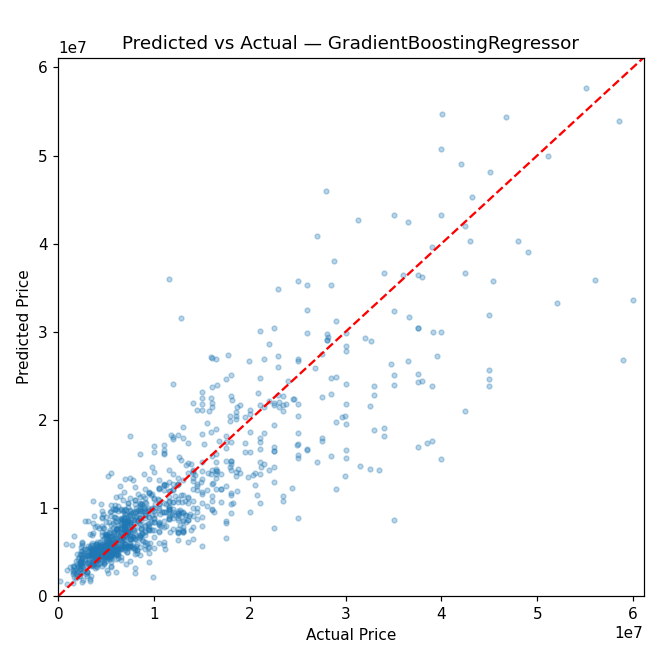

In [1]:
best_name = results_df.iloc[0]["model"]
best_model = fitted[best_name]
pred_best = np.expm1(best_model.predict(X_test))

plt.figure(figsize=(6,6))
plt.scatter(y_test, pred_best, alpha=0.3, s=10)
lims = [0, y_test.quantile(0.99)]
plt.plot(lims, lims, "r--")
plt.xlim(lims); plt.ylim(lims)
plt.xlabel("Actual Price"); plt.ylabel("Predicted Price")
plt.title(f"Predicted vs Actual -- {best_name}")
plt.show()

**Bonus: 5-fold cross-validation** on the winning model.

In [1]:
cv_scores = cross_val_score(best_model, X, y_log, cv=5, scoring="r2", n_jobs=-1)
print("5-fold CV R^2 (log target):", np.round(cv_scores, 4))
print("Mean CV R^2:", cv_scores.mean().round(4))

5-fold CV R^2 (log target): [0.5038 0.7153 0.8467 0.8164 0.6893]
Mean CV R^2: 0.7143


The cross-validation mean (0.71) is lower than the single held-out test score (0.86) --
some folds land on subsets of the smaller cities (Nagpur, Bangalore) with very few samples,
which makes them harder to generalize to. This is a useful sanity check: it shows the single
train/test split is somewhat optimistic, and more data per city would improve robustness.

## 2.6 Export the Model

In [1]:
joblib.dump(best_model, "house_price.pkl")

# Sanity check: reload and predict one sample
loaded = joblib.load("house_price.pkl")
sample = X_test.iloc[[0]]
sample_pred_log = loaded.predict(sample)
print("Reloaded prediction:", np.expm1(sample_pred_log))

Reloaded prediction: [16953866.79581908]


In [1]:
json.dump(sorted(df_clean["location_grouped"].unique().tolist()), open("locations.json", "w"))
print(df_clean["location_grouped"].nunique(), "locations saved to locations.json")

6 locations saved to locations.json


> **Version pinning:** a pickle only loads reliably with the same scikit-learn version.
> This notebook was run with scikit-learn 1.8.0 -- pin this exact version in `backend/requirements.txt`.

In [1]:
import sklearn
sklearn.__version__

"1.8.0"